# 🎮 Pixel Art Transformer — Build a Sprite Generator from Scratch

> *Draw the top half of a mushroom. Watch the model complete the bottom.*

---

## What you're building

A Transformer trained on 240 16×16 pixel art sprites that generates new ones
**row by row** — exactly like an artist working top to bottom.

Each row of a sprite is treated as a **token**. The model reads the top rows
and predicts what comes next. At the end you'll seed it with known sprites
and see what it imagines below the fold.

## Why this is different from the music notebook

The music notebook's tokens were single notes — obvious discrete units.
Here you build the tokens yourself from raw pixel data.
That pipeline (pixels → palette → rows → vocab) is the hardest part,
and it mirrors exactly what you'd do with any real-world vision dataset.

## Your 17 TODOs

| # | Section | Task | New? |
|---|---------|------|------|
| 1 | Data | `build_colour_map` — nearest-palette-colour lookup | 🆕 |
| 2 | Data | `quantise_sprite` — RGB image → palette IDs | 🆕 |
| 3 | Data | `sprite_to_rows` — 2-D grid → 16 row tuples | 🆕 |
| 4 | Data | `build_row_vocab` — unique rows → integer IDs | 🆕 |
| 5 | Data | `encode_sprite` — sprite → sequence of row IDs | 🆕 |
| 6 | Data | Sliding-window training pairs | same as music |
| 7 | Data | Build `row_pixels` tensor (vocab → pixel data) | 🆕 |
| 8 | Model | `RowEncoder.forward` — embed pixels, project | 🆕 |
| 9 | Model | `PositionalEncoding` — sin/cos formula | same as music |
| 10 | Model | `MultiHeadAttention.forward` — full attention | same as music |
| 11 | Model | `TransformerBlock.forward` — residuals + norms | same as music |
| 12 | Model | `PixelTransformer.__init__` — assemble | same as music |
| 13 | Train | Loss function + optimiser | same as music |
| 14 | Train | Backprop loop | same as music |
| 15 | Gen | `decode_sequence` — row IDs → pixel grid | 🆕 |
| 16 | Gen | `generate_sprite` — temperature sampling | same as music |
| 17 | Gen | `render_sprite` — display as image | 🆕 |

**Run cells top to bottom. Replace every `___` with code.**
Each blank has a hint comment above it, and a `💡 Hint` dropdown below.


## 🔧 Step 0 — Imports

*Just run this — no blanks.*

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("✅ Imports ready!")
print(f"   PyTorch {torch.__version__}")


✅ Imports ready!
   PyTorch 2.10.0+cu128


## 🎨 Step 1 — Dataset

*Just run these two cells — no blanks.*

We have 6 sprite **templates** (hero, mushroom, tree, house, potion, gem).
Each template is a 16×16 pattern where numbers 1–9 represent body parts.
We apply **40 random colour schemes** to each template = **240 training sprites**.

Each sprite is returned as a 16×16×3 **RGB image** with mild pixel noise added
to simulate the imperfections of real-world sprites.
Your first job (TODO 1–2) will be to quantise these back to palette indices.


In [2]:
# ── Fixed 16-colour palette (NES-inspired) ───────────────────────────────────
PALETTE = np.array([
    [  0,   0,   0],  #  0  black        (background)
    [255, 255, 255],  #  1  white
    [220,  60,  60],  #  2  red
    [ 60, 180,  60],  #  3  green
    [ 60,  80, 220],  #  4  blue
    [220, 200,  50],  #  5  yellow
    [160,  90,  30],  #  6  brown
    [150,  50, 200],  #  7  purple
    [ 50, 200, 200],  #  8  cyan
    [255, 160,  60],  #  9  orange
    [255, 180, 180],  # 10  pink
    [130, 130, 130],  # 11  grey
    [255, 215,  80],  # 12  gold
    [ 30, 130, 130],  # 13  teal
    [240, 120,  80],  # 14  coral
    [220, 235, 220],  # 15  off-white
], dtype=np.uint8)

NUM_COLOURS = len(PALETTE)   # 16
print(f"Palette: {NUM_COLOURS} colours")

# ── Sprite templates ─────────────────────────────────────────────────────────
# Each cell is a template-colour ID (0 = background, 1-9 = body parts).
# These get replaced by random palette colours during dataset generation.

def _t(rows):
    out = np.zeros((16, 16), dtype=np.uint8)
    for r, s in enumerate(rows):
        for c, ch in enumerate(s.ljust(16)[:16]):
            out[r, c] = int(ch) if ch.isdigit() else 0
    return out

TEMPLATES = {
    "hero": _t([
        "0000011111100000",
        "0000122222210000",
        "0000122222210000",
        "0000122222210000",
        "0000012222100000",
        "0000033333300000",
        "0000333333330000",
        "0000333333330000",
        "0000333333330000",
        "0000433333340000",
        "0000440000440000",
        "0000440000440000",
        "0000440000440000",
        "0000440000440000",
        "0000550000550000",
        "0000550000550000",
    ]),
    "mushroom": _t([
        "0000000000000000",
        "0000011100000000",
        "0000111110000000",
        "0001211121000000",
        "0012111121200000",
        "0012111111200000",
        "0001211121000000",
        "0000111110000000",
        "0000022200000000",
        "0000222220000000",
        "0000232232000000",
        "0000232232000000",
        "0000022200000000",
        "0000000000000000",
        "0000000000000000",
        "0000000000000000",
    ]),
    "tree": _t([
        "0000000000000000",
        "0000000300000000",
        "0000003330000000",
        "0000033333000000",
        "0000333333300000",
        "0003333333330000",
        "0033333133330000",
        "0333331133333000",
        "0003333333330000",
        "0000003630000000",
        "0000003630000000",
        "0000006660000000",
        "0000006660000000",
        "0000066666000000",
        "0000000000000000",
        "0000000000000000",
    ]),
    "house": _t([
        "0000000000000000",
        "0000000200000000",
        "0000002220000000",
        "0000022222000000",
        "0000222222200000",
        "0002222222220000",
        "0001111111110000",
        "0001111111110000",
        "0001113311110000",
        "0001113311110000",
        "0001114411110000",
        "0001114411110000",
        "0001114411110000",
        "0001111111110000",
        "0000000000000000",
        "0000000000000000",
    ]),
    "potion": _t([
        "0000000000000000",
        "0000000000000000",
        "0000001100000000",
        "0000001100000000",
        "0000011110000000",
        "0000122210000000",
        "0001122221000000",
        "0001133221000000",
        "0001133221000000",
        "0001122221000000",
        "0001122221000000",
        "0000122210000000",
        "0000011110000000",
        "0000001100000000",
        "0000000000000000",
        "0000000000000000",
    ]),
    "gem": _t([
        "0000000000000000",
        "0000000000000000",
        "0000011111000000",
        "0000111111100000",
        "0001111111110000",
        "0011121112110000",
        "0011211211210000",
        "0001121211100000",
        "0000112211000000",
        "0000011110000000",
        "0000001100000000",
        "0000000000000000",
        "0000000000000000",
        "0000000000000000",
        "0000000000000000",
        "0000000000000000",
    ]),
}


def build_sprite_dataset(n_per_template=40, noise_std=5):
    """
    Generate n_per_template colour variations for every template.
    Returns a list of (16, 16, 3) uint8 RGB arrays.
    """
    sprites = []
    for name, template in TEMPLATES.items():
        unique_parts = sorted(set(template.flatten()) - {0})
        for _ in range(n_per_template):
            # Randomly assign palette colours to template parts
            palette_pool = random.sample(range(1, NUM_COLOURS), len(unique_parts))
            mapping = {0: 0, **{p: c for p, c in zip(unique_parts, palette_pool)}}
            ids  = np.vectorize(mapping.get)(template).astype(np.uint8)
            rgb  = PALETTE[ids].copy()
            # Add mild noise to simulate real-world sprites
            noise = np.random.randint(-noise_std, noise_std+1, rgb.shape, dtype=np.int16)
            rgb   = np.clip(rgb.astype(np.int16) + noise, 0, 255).astype(np.uint8)
            sprites.append(rgb)
    random.shuffle(sprites)
    return sprites


SPRITES_RGB = build_sprite_dataset(n_per_template=40)

print(f"✅ Dataset built: {len(SPRITES_RGB)} sprites")
print(f"   Each sprite shape: {SPRITES_RGB[0].shape}  (height × width × RGB)")
print(f"   Templates: {list(TEMPLATES.keys())}")


Palette: 16 colours
✅ Dataset built: 240 sprites
   Each sprite shape: (16, 16, 3)  (height × width × RGB)
   Templates: ['hero', 'mushroom', 'tree', 'house', 'potion', 'gem']


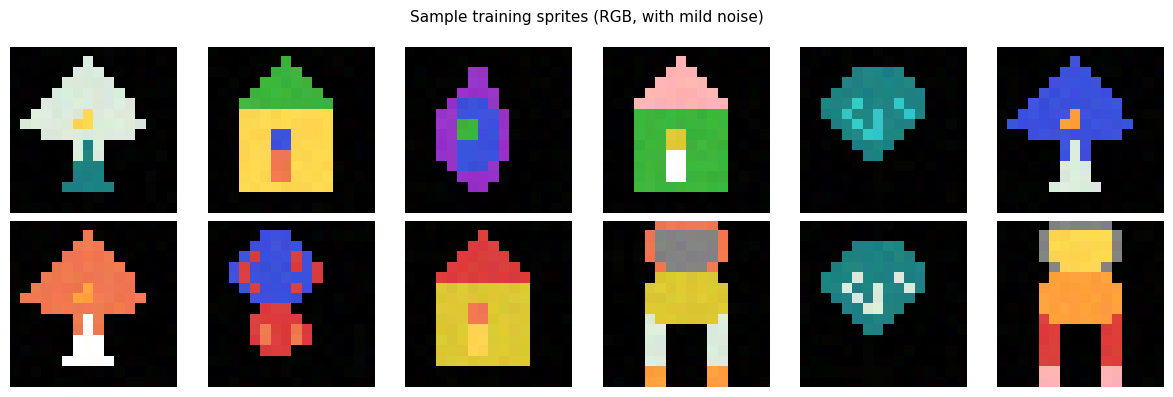

These are the raw RGB images. Your next job: quantise them back to palette IDs.


In [3]:
# ── Display 12 sample sprites ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, sprite in zip(axes.flat, SPRITES_RGB[:12]):
    ax.imshow(sprite, interpolation='nearest', aspect='equal')
    ax.axis('off')
fig.suptitle("Sample training sprites (RGB, with mild noise)", fontsize=11, fontweight='500')
plt.tight_layout()
plt.show()
print("These are the raw RGB images. Your next job: quantise them back to palette IDs.")


## 🖌️ Step 2 — Colour Pipeline

The sprites were generated from `PALETTE` with mild noise added.
You need to map every pixel back to its **nearest palette colour**.

```
RGB pixel  →  find nearest colour in PALETTE  →  palette index  (0–15)
```

This is called **colour quantisation** and is a fundamental step in
any pixel art / retro-style image processing pipeline.


In [4]:
def build_colour_map(palette):
    """
    Pre-compute a lookup table from EVERY possible 24-bit RGB colour
    to its nearest palette index.

    With 256^3 = 16M possible colours this would be huge, so instead
    we return a function (closure) that computes the nearest index on demand.

    Args
    ----
    palette : np.ndarray  shape (NUM_COLOURS, 3)  dtype uint8

    Returns
    -------
    nearest_id : callable  (rgb_pixel: array-like of shape (3,)) -> int
    """
    def nearest_id(pixel):
        pixel = np.array(pixel, dtype=np.int32)

        # TODO 1: Find the index of the palette colour closest to `pixel`.
        #
        # Steps:
        #   1. Compute the squared distance from `pixel` to EVERY palette colour.
        #      For one palette row p: squared_dist = sum((p - pixel)**2)
        #      For all rows at once:  dists = np.sum((palette.astype(np.int32) - pixel)**2, axis=1)
        #   2. Return the index of the minimum distance.
        #      Hint: np.argmin(...)
        #
        dists = np.sum((palette.astype(np.int32) - pixel) ** 2, axis=1)   # shape (NUM_COLOURS,) — one distance per palette entry
        return int(np.argmin(dists))

    return nearest_id

nearest_colour = build_colour_map(PALETTE)

# Quick tests
print("Test nearest_colour:")
print(f"  Pure black   (0,0,0)     → id {nearest_colour([0,0,0])}  (expect 0)")
print(f"  Pure white   (255,255,255) → id {nearest_colour([255,255,255])}  (expect 1)")
print(f"  Near-red     (218,58,62) → id {nearest_colour([218,58,62])}  (expect 2)")


Test nearest_colour:
  Pure black   (0,0,0)     → id 0  (expect 0)
  Pure white   (255,255,255) → id 1  (expect 1)
  Near-red     (218,58,62) → id 2  (expect 2)


<details>
<summary>💡 Hint — TODO 1</summary>

```python
dists = np.sum((palette.astype(np.int32) - pixel) ** 2, axis=1)
```

**Why cast to `int32` first?**
`palette` is `uint8` (0–255). Subtracting two uint8 values wraps around
(e.g. `50 - 220` gives `86` instead of `-170`). Casting to `int32` first
allows negative differences to be represented correctly before squaring.

**Why squared distance and not just distance?**
Squaring avoids computing `sqrt`, which is slower and unnecessary —
the index of the minimum doesn't change.
</details>


In [5]:
def quantise_sprite(rgb_img, palette, nearest_id_fn):
    """
    Convert a (H, W, 3) uint8 RGB image to a (H, W) array of palette indices.

    Args
    ----
    rgb_img      : np.ndarray  shape (H, W, 3)  dtype uint8
    palette      : np.ndarray  shape (NUM_COLOURS, 3)
    nearest_id_fn: the callable returned by build_colour_map()

    Returns
    -------
    ids : np.ndarray  shape (H, W)  dtype uint8
          Every value is in range [0, NUM_COLOURS)
    """
    H, W, _ = rgb_img.shape
    ids = np.zeros((H, W), dtype=np.uint8)

    # TODO 2: Fill `ids` by calling nearest_id_fn on each pixel.
    #
    # Iterate over every (row, col) position.
    # Hint:
    #   for r in range(H):
    #       for c in range(W):
    #           ids[r, c] = nearest_id_fn(rgb_img[r, c])
    #
    # (A vectorised solution is fine too, but the loop version is clearest.)
    for r in range(H):
        for c in range(W):
            ids[r, c] = nearest_id_fn(rgb_img[r, c])

    return ids

# ── Test on one sprite ────────────────────────────────────────────────────────
sample_ids = quantise_sprite(SPRITES_RGB[0], PALETTE, nearest_colour)
print(f"Quantised sprite shape : {sample_ids.shape}")
print(f"Unique palette IDs used: {sorted(set(sample_ids.flatten()))}")
print(f"All values in [0,15]   : {sample_ids.max() <= 15}")
print()
print("First 4 rows of colour IDs:")
print(sample_ids[:4])


Quantised sprite shape : (16, 16)
Unique palette IDs used: [np.uint8(0), np.uint8(12), np.uint8(13), np.uint8(15)]
All values in [0,15]   : True

First 4 rows of colour IDs:
[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 15  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 15 15 15  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 15 15 15 15 15  0  0  0  0  0  0]]


<details>
<summary>💡 Hint — TODO 2</summary>

```python
for r in range(H):
    for c in range(W):
        ids[r, c] = nearest_id_fn(rgb_img[r, c])
```

**Why a nested loop and not numpy broadcasting?**
`nearest_id_fn` is a Python function that processes one pixel at a time.
You *could* vectorise with `np.apply_along_axis`, but the loop is cleaner
to read and fast enough here (256 pixels per sprite).

**How would you make it faster for large images?**
Vectorise the distance computation directly:
```python
pixels = rgb_img.reshape(-1, 3).astype(np.int32)          # (H*W, 3)
dists  = np.sum((palette[None] - pixels[:, None])**2, -1)  # (H*W, 16)
ids    = np.argmin(dists, axis=1).reshape(H, W)
```
</details>


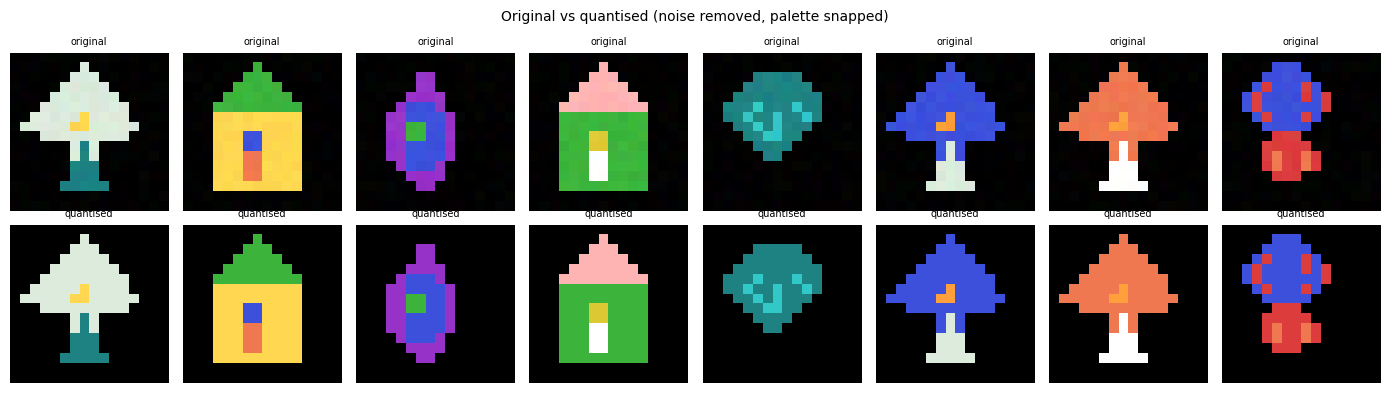

✅ All 240 sprites quantised successfully.


In [6]:
# ── Quantise all sprites and visually verify round-trip ──────────────────────
SPRITES_IDS = [quantise_sprite(s, PALETTE, nearest_colour) for s in SPRITES_RGB]

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(SPRITES_RGB[i], interpolation='nearest')
    axes[0, i].axis('off')
    axes[0, i].set_title("original", fontsize=7)

    axes[1, i].imshow(PALETTE[SPRITES_IDS[i]], interpolation='nearest')
    axes[1, i].axis('off')
    axes[1, i].set_title("quantised", fontsize=7)

fig.suptitle("Original vs quantised (noise removed, palette snapped)", fontsize=10, fontweight='500')
plt.tight_layout()
plt.show()
print(f"✅ All {len(SPRITES_IDS)} sprites quantised successfully.")


## 🧩 Step 3 — Row Tokenisation

A quantised sprite is a 16×16 grid of palette IDs.
We now split each sprite into **16 rows**, where each row is a sequence
of 16 colour IDs. Then we build a **vocabulary** mapping each unique row
to an integer token ID — just like a word vocabulary in NLP.

```
sprite (16×16)  →  16 row tuples  →  16 row token IDs
```

Why tuples? Because Python dicts require hashable keys, and lists are not hashable.


In [7]:
def sprite_to_rows(sprite_ids):
    """
    Split a (16, 16) palette-ID array into a list of 16 row tuples.

    Args
    ----
    sprite_ids : np.ndarray  shape (16, 16)  dtype uint8

    Returns
    -------
    rows : list of 16 tuples, each tuple has 16 ints (palette IDs)

    Example
    -------
    sprite_ids[0]  = [3, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 3, 0, 0, 0, 0]
    rows[0]        = (3, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 3, 0, 0, 0, 0)
    """
    # TODO 3: Convert each row of sprite_ids into a tuple and collect them.
    #
    # Hint:  rows = [tuple(sprite_ids[r]) for r in range(16)]
    #
    rows = [tuple(sprite_ids[r]) for r in range(16)]
    return rows

# Test
test_rows = sprite_to_rows(SPRITES_IDS[0])
print(f"Number of rows  : {len(test_rows)}")
print(f"Type of row     : {type(test_rows[0])}")
print(f"Length of row   : {len(test_rows[0])}")
print(f"Row 0           : {test_rows[0]}")


Number of rows  : 16
Type of row     : <class 'tuple'>
Length of row   : 16
Row 0           : (np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))


<details>
<summary>💡 Hint — TODO 3</summary>

```python
rows = [tuple(sprite_ids[r]) for r in range(16)]
```

Or equivalently: `rows = [tuple(row) for row in sprite_ids]`

**Why tuples and not lists?**
We're about to use these rows as **dictionary keys** in TODO 4.
Python dict keys must be *hashable* — tuples are, lists are not.
`hash((3, 0, 0, 1))` works; `hash([3, 0, 0, 1])` raises `TypeError`.
</details>


In [8]:
def build_row_vocab(all_row_sequences):
    """
    Collect every unique row tuple across all sprites and assign it an integer ID.

    Args
    ----
    all_row_sequences : list of lists — each inner list is the 16-row sequence
                        for one sprite (as returned by sprite_to_rows)

    Returns
    -------
    row_to_id : dict  {row_tuple: int}   — row  →  token ID
    id_to_row : dict  {int: row_tuple}   — token ID  →  row
    """
    # TODO 4: Build row_to_id and id_to_row.
    #
    # Steps:
    #   1. Collect all unique row tuples into a set, then sort for determinism.
    #      unique_rows = sorted(set(row for seq in all_row_sequences for row in seq))
    #   2. Build row_to_id: {row: idx for idx, row in enumerate(unique_rows)}
    #   3. Build id_to_row: the reverse mapping.

    unique_rows = sorted(set(row for seq in all_row_sequences for row in seq))
    row_to_id   = {row: idx for idx, row in enumerate(unique_rows)}
    id_to_row   = {idx: row for row, idx in row_to_id.items()}

    return row_to_id, id_to_row

all_row_sequences = [sprite_to_rows(s) for s in SPRITES_IDS]
row_to_id, id_to_row = build_row_vocab(all_row_sequences)

ROW_VOCAB_SIZE = len(row_to_id)
print(f"✅ Row vocabulary built")
print(f"   Unique rows (tokens) : {ROW_VOCAB_SIZE}")
print(f"   240 sprites × 16 rows = {240*16} rows total, {ROW_VOCAB_SIZE} unique")


✅ Row vocabulary built
   Unique rows (tokens) : 879
   240 sprites × 16 rows = 3840 rows total, 879 unique


<details>
<summary>💡 Hint — TODO 4</summary>

```python
unique_rows = sorted(set(row for seq in all_row_sequences for row in seq))
row_to_id   = {row: idx for idx, row in enumerate(unique_rows)}
id_to_row   = {idx: row for row, idx in row_to_id.items()}
```

**The double `for` in the set comprehension:**
`for seq in all_row_sequences` iterates over sprites.
`for row in seq` iterates over the 16 rows of each sprite.
Together they flatten all rows from all sprites into one stream.

**Why `sorted(set(...))`?**
`set` gives unique rows but in arbitrary order.
`sorted` makes the vocab deterministic — same run, same IDs every time.
Without sorting, `row_to_id` would be different on every run, making saved
models incompatible with reloaded vocabs.
</details>


In [9]:
def encode_sprite(sprite_ids, row_to_id):
    """
    Convert a (16, 16) palette-ID array to a list of 16 row token IDs.

    Args
    ----
    sprite_ids : np.ndarray  shape (16, 16)
    row_to_id  : dict  {row_tuple: int}

    Returns
    -------
    token_ids : list of 16 ints
    """
    # TODO 5: Convert each row of sprite_ids into its row token ID.
    #
    # Step 1: Call sprite_to_rows(sprite_ids) to get a list of 16 row tuples.
    # Step 2: For each row tuple, look up its ID in row_to_id.
    # Hint:   [row_to_id[row] for row in rows]
    #
    rows      = sprite_to_rows(sprite_ids)
    token_ids = [row_to_id[row] for row in rows]
    return token_ids

# Test
test_encoded = encode_sprite(SPRITES_IDS[0], row_to_id)
print(f"Encoded sprite: {test_encoded}")
print(f"Type          : {type(test_encoded)}, length = {len(test_encoded)}")
print(f"All IDs valid  : {all(0 <= t < ROW_VOCAB_SIZE for t in test_encoded)}")


Encoded sprite: [0, 15, 83, 181, 424, 656, 838, 878, 656, 81, 81, 72, 72, 166, 0, 0]
Type          : <class 'list'>, length = 16
All IDs valid  : True


<details>
<summary>💡 Hint — TODO 5</summary>

```python
rows      = sprite_to_rows(sprite_ids)
token_ids = [row_to_id[row] for row in rows]
```

`encode_sprite` is intentionally short — it just chains TODO 3 and TODO 4.
The value of writing it as its own function is that you can call it once
per sprite and cache the result, rather than re-computing `sprite_to_rows`
every time.
</details>


In [10]:
# ── TODO 6: Build sliding-window training pairs ──────────────────────────────
#
# For each encoded sprite (a sequence of 16 row IDs), create overlapping
# (context, target) pairs exactly like the music notebook:
#
#   context = [row_0, row_1, ..., row_{CONTEXT_LEN-1}]  →  target = row_{CONTEXT_LEN}
#   context = [row_1, row_2, ..., row_{CONTEXT_LEN}  ]  →  target = row_{CONTEXT_LEN+1}
#   ...
#
# Build:
#   X_list : list of lists — each is CONTEXT_LEN row IDs
#   y_list : list of ints  — each is the next row ID
# Then convert both to LongTensors.
#
# Hint (same pattern as music notebook):
#   for seq in encoded_sprites:
#       for i in range(len(seq) - CONTEXT_LEN):
#           X_list.append(seq[i : i + CONTEXT_LEN])
#           y_list.append(seq[i + CONTEXT_LEN])

CONTEXT_LEN = 8   # model sees 8 rows, predicts the 9th

encoded_sprites = [encode_sprite(s, row_to_id) for s in SPRITES_IDS]

X_list, y_list = [], []
for seq in encoded_sprites:
    for i in range(len(seq) - CONTEXT_LEN):
        X_list.append(seq[i : i + CONTEXT_LEN])   # context window
        y_list.append(seq[i + CONTEXT_LEN])   # target row ID

X_all = torch.tensor(X_list, dtype=torch.long)   # (N, CONTEXT_LEN)
y_all = torch.tensor(y_list, dtype=torch.long)   # (N,)

print(f"✅ Training windows: {len(X_all)}")
print(f"   X_all shape : {X_all.shape}")
print(f"   y_all shape : {y_all.shape}")
print(f"\nExample window #0:")
print(f"  Context row IDs : {X_all[0].tolist()}")
print(f"  Target  row ID  : {y_all[0].item()}")


✅ Training windows: 1920
   X_all shape : torch.Size([1920, 8])
   y_all shape : torch.Size([1920])

Example window #0:
  Context row IDs : [0, 15, 83, 181, 424, 656, 838, 878]
  Target  row ID  : 656


<details>
<summary>💡 Hint — TODO 6</summary>

```python
X_list.append(seq[i : i + CONTEXT_LEN])
y_list.append(seq[i + CONTEXT_LEN])
```

**Why `CONTEXT_LEN = 8` (half the sprite)?**
The model sees the top half and predicts the bottom half.
During generation you'll seed with the top 8 rows of any sprite
and generate the remaining 8 rows. Choosing half means neither the seed
nor the generated part is trivially short.
</details>


## 🔗 Step 4 — The `row_pixels` Tensor

This is a bridge between the **vocabulary** and the **model**.

The model doesn't embed row tokens with a plain `nn.Embedding` lookup.
Instead it looks up the actual **pixel data** for each token — the 16 colour IDs
in that row — and feeds those through a richer `RowEncoder` that understands
pixel-level similarity.

`row_pixels` is a tensor of shape `(VOCAB_SIZE, 16)`:
- Row `i` contains the 16 colour IDs for row token `i`.
- It's a fixed lookup table, not a learnable parameter.

Two rows that differ by only one pixel will have very similar `RowEncoder`
embeddings — something a plain `nn.Embedding` can never learn.


In [11]:
# TODO 7: Build the row_pixels tensor.
#
# row_pixels[i] should contain the 16 colour IDs for row token i.
# You can get the pixel data for token i by looking up id_to_row[i].
#
# Steps:
#   1. Allocate: row_pixels = torch.zeros(ROW_VOCAB_SIZE, 16, dtype=torch.long)
#   2. For each (row_tuple, token_id) pair in row_to_id.items():
#          row_pixels[token_id] = torch.tensor(list(row_tuple), dtype=torch.long)
#
# Hint: a single loop over row_to_id.items() is all you need.

row_pixels = torch.zeros(ROW_VOCAB_SIZE, 16, dtype=torch.long)   # shape (VOCAB_SIZE, 16)

for row_tuple, token_id in row_to_id.items():
    row_pixels[token_id] = torch.tensor(list(row_tuple), dtype=torch.long)

print(f"row_pixels shape  : {row_pixels.shape}")
print(f"row_pixels dtype  : {row_pixels.dtype}")
print(f"Max colour ID     : {row_pixels.max().item()}  (should be ≤ 15)")
print(f"\nrow_pixels[0] = {row_pixels[0].tolist()}  ← pixel data for token 0")
print(f"id_to_row[0]  = {list(id_to_row[0])}  ← should match above")


row_pixels shape  : torch.Size([879, 16])
row_pixels dtype  : torch.int64
Max colour ID     : 15  (should be ≤ 15)

row_pixels[0] = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  ← pixel data for token 0
id_to_row[0]  = [np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0)]  ← should match above


<details>
<summary>💡 Hint — TODO 7</summary>

```python
row_pixels = torch.zeros(ROW_VOCAB_SIZE, 16, dtype=torch.long)
for row_tuple, token_id in row_to_id.items():
    row_pixels[token_id] = torch.tensor(list(row_tuple), dtype=torch.long)
```

**Why `dtype=torch.long`?**
Colour IDs (0–15) will be used as indices into `nn.Embedding` inside `RowEncoder`.
PyTorch embedding lookups require `LongTensor` (int64) indices — passing floats
or int32 raises a `RuntimeError`.

**Why `list(row_tuple)` before `torch.tensor`?**
`torch.tensor` accepts a plain Python list or numpy array.
A tuple also works, but the explicit conversion makes the intent clearer.
</details>


## 🏗️ Step 5 — Model Architecture

```
row IDs  (B, T)
  │  lookup row_pixels table  →  pixel IDs  (B, T, 16)
  ↓
RowEncoder          ← NEW — embeds each pixel colour, projects to d_model
  ↓
PositionalEncoding  ← same as music notebook
  ↓
TransformerBlock × 2
  ├─ MultiHeadAttention  (4 heads, causal mask)
  └─ FFN  (GELU)
  both with residual + LayerNorm
  ↓
Linear output head  →  logits  (B, T, VOCAB_SIZE)
```

The `RowEncoder` is the key new component. It treats a row's 16 pixels as
a small sequence of colour tokens, embeds each independently, and projects
the concatenation to `d_model`. This means two rows that differ by one pixel
have similar encodings — something a plain word-embedding lookup can't do.


In [12]:
COLOUR_DIM = 8    # embedding size per colour inside RowEncoder
D_MODEL    = 64   # main model dimension
N_HEADS    = 4    # attention heads  (D_MODEL ÷ N_HEADS = 16 per head)
D_FF       = 128  # FFN hidden size
N_LAYERS   = 2    # stacked transformer blocks
DROPOUT    = 0.1

print(f"RowEncoder  : {NUM_COLOURS} colours × {COLOUR_DIM}d → flatten {16*COLOUR_DIM}d → project {D_MODEL}d")
print(f"Transformer : d_model={D_MODEL}, {N_HEADS} heads, {N_LAYERS} layers, d_ff={D_FF}")
print(f"Output head : {D_MODEL}d → {ROW_VOCAB_SIZE} row vocab")


RowEncoder  : 16 colours × 8d → flatten 128d → project 64d
Transformer : d_model=64, 4 heads, 2 layers, d_ff=128
Output head : 64d → 879 row vocab


In [13]:
class RowEncoder(nn.Module):
    """
    Encodes a row of 16 colour IDs into a single d_model-dimensional vector.

    Unlike a plain nn.Embedding (one vector per token), the RowEncoder
    shares colour embeddings across all row positions, so similar rows
    produce similar output vectors.

    Forward pass:
        Input  : (B, T, 16)   — 16 colour IDs per row
        Embed  : (B, T, 16, colour_dim)
        Flatten: (B, T, 16 * colour_dim)
        Project: (B, T, d_model)
    """
    def __init__(self, num_colours, colour_dim, d_model):
        super().__init__()
        self.colour_dim = colour_dim
        # One embedding vector per palette colour
        self.colour_emb = nn.Embedding(num_colours, colour_dim)
        # Project concatenated pixel embeddings to model dimension
        self.proj       = nn.Linear(16 * colour_dim, d_model)

    def forward(self, x):
        # x: (B, T, 16) — 16 colour IDs per row
        B, T, P = x.shape   # P = 16 (pixels per row)

        # TODO 8a: Embed each colour ID.
        # self.colour_emb(x)  →  shape (B, T, P, colour_dim)
        # Hint: embedded = self.colour_emb(x)
        embedded = self.colour_emb(x)

        # TODO 8b: Flatten the pixel dimension.
        # Merge the last two dims: (B, T, P, colour_dim) → (B, T, P * colour_dim)
        # Hint: embedded.view(B, T, P * self.colour_dim)
        flat = embedded.view(B, T, P * self.colour_dim)

        # TODO 8c: Project to d_model and return.
        # Hint: self.proj(flat)  →  (B, T, d_model)
        return self.proj(flat)

# ── Shape test ────────────────────────────────────────────────────────────────
_enc = RowEncoder(NUM_COLOURS, COLOUR_DIM, D_MODEL)
_x   = torch.randint(0, NUM_COLOURS, (2, 8, 16))   # batch=2, seq=8, pixels=16
_out = _enc(_x)
print("RowEncoder output shape:", _out.shape)
assert _out.shape == (2, 8, D_MODEL), "❌ Check your embed/view/proj steps"
print("✅ RowEncoder — shape correct!")


RowEncoder output shape: torch.Size([2, 8, 64])
✅ RowEncoder — shape correct!


<details>
<summary>💡 Hint — TODO 8</summary>

```python
embedded = self.colour_emb(x)                       # (B, T, 16, colour_dim)
flat     = embedded.view(B, T, P * self.colour_dim) # (B, T, 128)
return   self.proj(flat)                            # (B, T, d_model)
```

**Why `.view()` and not `.reshape()`?**
Both work here because `embedded` is already contiguous in memory
(it came straight from `nn.Embedding`). `.view()` is a zero-copy operation
that just changes the shape metadata; `.reshape()` may allocate a copy.
Use `.view()` when you're confident the tensor is contiguous; otherwise
use `.contiguous().view()` or just `.reshape()`.

**What does the RowEncoder actually learn?**
After training, the 16-entry colour embedding table (`self.colour_emb.weight`)
will arrange colours so that similar ones (e.g. two shades of green) are nearby.
The linear projection then learns which colour *patterns* are most predictive
of the next row — essentially, it discovers what "horizontal structure" matters.
</details>


In [14]:
class PositionalEncoding(nn.Module):
    """
    Adds a fixed sin/cos position fingerprint to each row embedding.
    Identical to the music notebook — included here for completeness.
    """
    def __init__(self, d_model, max_len=50, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        # TODO 9a: Fill even columns with sin
        pe[:, 0::2] = torch.sin(position * div_term)
        # TODO 9b: Fill odd columns with cos
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

_pe = PositionalEncoding(D_MODEL)
assert _pe(torch.zeros(2, 8, D_MODEL)).shape == (2, 8, D_MODEL)
print("✅ PositionalEncoding — shape correct!")


✅ PositionalEncoding — shape correct!


<details>
<summary>💡 Hint — TODO 9</summary>

```python
pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)
```

Same as the music notebook. If you've done that one, copy it directly.
</details>


In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.shape
        Q = self.W_q(x);  K = self.W_k(x);  V = self.W_v(x)

        # TODO 10a: Split Q, K, V into n_heads.
        # Target shape: (B, n_heads, T, d_head)
        # Hint: .view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        Q = Q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # TODO 10b: Scaled dot-product scores.
        # Hint: torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)

        # Causal mask — provided, do not change
        mask   = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        # TODO 10c: Softmax weights, then weighted sum of V.
        weights = F.softmax(scores, dim=-1)                          # F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        context = torch.matmul(weights, V)                          # torch.matmul(weights, V)

        # TODO 10d: Merge heads → (B, T, D).
        # Hint: context.transpose(1, 2).contiguous().view(B, T, self.d_model)
        context = context.transpose(1, 2).contiguous().view(B, T, self.d_model)

        return self.W_o(context)

_mha = MultiHeadAttention(D_MODEL, N_HEADS)
assert _mha(torch.randn(2, 8, D_MODEL)).shape == (2, 8, D_MODEL)
print("✅ MultiHeadAttention — shape correct!")


✅ MultiHeadAttention — shape correct!


<details>
<summary>💡 Hint — TODO 10</summary>

```python
K       = K.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
V       = V.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
scores  = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
weights = F.softmax(scores, dim=-1)
context = torch.matmul(weights, V)
context = context.transpose(1, 2).contiguous().view(B, T, self.d_model)
```

Same as the music notebook. The architecture doesn't change just because
the tokens are pixel rows instead of musical notes.
</details>


In [16]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn     = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # TODO 11a: Attention sub-layer with residual + LayerNorm.
        # Pattern: x = self.norm1(x + self.dropout(sublayer(x)))
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout(attn_out))

        # TODO 11b: FFN sub-layer with residual + LayerNorm.
        ffn_out  = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

_blk = TransformerBlock(D_MODEL, N_HEADS, D_FF)
assert _blk(torch.randn(2, 8, D_MODEL)).shape == (2, 8, D_MODEL)
print("✅ TransformerBlock — shape correct!")


✅ TransformerBlock — shape correct!


<details>
<summary>💡 Hint — TODO 11</summary>

```python
attn_out = self.attn(x)
x        = self.norm1(x + self.dropout(attn_out))

ffn_out  = self.ffn(x)
x        = self.norm2(x + self.dropout(ffn_out))
```

Same as the music notebook. The residual + norm pattern is the same
regardless of whether tokens are words, notes, or pixel rows.
</details>


In [17]:
class PixelTransformer(nn.Module):
    """
    Decoder-only Transformer for sprite generation.

    Key difference from a text/music transformer:
    Input tokens are row IDs, but they're embedded via RowEncoder
    (pixel-aware) rather than a plain nn.Embedding (ID-lookup only).
    The row_pixels buffer bridges the two representations.
    """
    def __init__(self, vocab_size, row_pixels, num_colours, colour_dim,
                 d_model, n_heads, d_ff, n_layers, max_len=50, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        # Store pixel lookup table as a non-learnable buffer
        self.register_buffer('row_pixels', row_pixels)

        # TODO 12a: RowEncoder — (num_colours, colour_dim, d_model)
        self.row_encoder = RowEncoder(num_colours, colour_dim, d_model)

        # TODO 12b: PositionalEncoding — (d_model, max_len, dropout)
        self.pos_enc     = PositionalEncoding(d_model, max_len, dropout)

        # TODO 12c: Stack of n_layers TransformerBlocks in an nn.ModuleList
        self.blocks      = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

        # TODO 12d: Output projection  d_model → vocab_size
        self.output_proj = nn.Linear(d_model, vocab_size)

    def forward(self, row_ids):
        # row_ids: (B, T) — sequence of row token IDs
        pixels = self.row_pixels[row_ids]                 # (B, T, 16)  lookup
        x      = self.row_encoder(pixels)                 # (B, T, D_MODEL)
        x      = x * math.sqrt(self.d_model)              # scale
        x      = self.pos_enc(x)                          # add position
        for block in self.blocks:
            x  = block(x)                                 # (B, T, D_MODEL)
        return self.output_proj(x)                        # (B, T, VOCAB_SIZE)

model = PixelTransformer(
    vocab_size  = ROW_VOCAB_SIZE,
    row_pixels  = row_pixels,
    num_colours = NUM_COLOURS,
    colour_dim  = COLOUR_DIM,
    d_model     = D_MODEL,
    n_heads     = N_HEADS,
    d_ff        = D_FF,
    n_layers    = N_LAYERS,
    dropout     = DROPOUT,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ PixelTransformer created!  Parameters: {n_params:,}")

_test  = torch.randint(0, ROW_VOCAB_SIZE, (4, CONTEXT_LEN))
_out   = model(_test)
print(f"   Input  shape: {_test.shape}  (batch=4, context={CONTEXT_LEN})")
print(f"   Output shape: {_out.shape}  (batch=4, context={CONTEXT_LEN}, vocab={ROW_VOCAB_SIZE})")
assert _out.shape == (4, CONTEXT_LEN, ROW_VOCAB_SIZE)
print("✅ End-to-end forward pass — shape correct!")


✅ PixelTransformer created!  Parameters: 131,951
   Input  shape: torch.Size([4, 8])  (batch=4, context=8)
   Output shape: torch.Size([4, 8, 879])  (batch=4, context=8, vocab=879)
✅ End-to-end forward pass — shape correct!


<details>
<summary>💡 Hint — TODO 12</summary>

```python
self.row_encoder = RowEncoder(num_colours, colour_dim, d_model)
self.pos_enc     = PositionalEncoding(d_model, max_len, dropout)
self.blocks      = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff, dropout)
                                  for _ in range(n_layers)])
self.output_proj = nn.Linear(d_model, vocab_size)
```

**Why `register_buffer('row_pixels', row_pixels)` instead of storing it as a plain attribute?**
`register_buffer` tells PyTorch to:
1. Include it when you call `model.state_dict()` (it gets saved/loaded with the model).
2. Move it automatically when you call `model.to(device)` (CPU ↔ GPU).
A plain `self.row_pixels = row_pixels` would do neither.
</details>


## 🏋️ Step 6 — Training

In [18]:
BATCH_SIZE = 32
NUM_EPOCHS = 400
LR         = 5e-4

# TODO 13a: Cross-entropy loss function.
# Hint: nn.CrossEntropyLoss()
loss_fn = nn.CrossEntropyLoss()

# TODO 13b: Adam optimiser on all model parameters.
# Hint: torch.optim.Adam(model.parameters(), lr=LR)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-5
)

print(f"✅ Loss: {loss_fn}")
print(f"✅ Optimiser: Adam  lr={LR}")
print(f"   Random baseline loss: log({ROW_VOCAB_SIZE}) = {math.log(ROW_VOCAB_SIZE):.3f}")


✅ Loss: CrossEntropyLoss()
✅ Optimiser: Adam  lr=0.0005
   Random baseline loss: log(879) = 6.779


<details>
<summary>💡 Hint — TODO 13</summary>

```python
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
```

The random-guessing baseline is `log(ROW_VOCAB_SIZE)`.
If your loss stays near that value after 100 epochs something is wrong —
check that your TODOs 1–12 all executed without error.
</details>


In [19]:
model.train()
loss_history = []

print(f"Training for {NUM_EPOCHS} epochs  "
      f"({len(X_all)} windows, batch={BATCH_SIZE})...")
print(f"Random baseline ≈ {math.log(ROW_VOCAB_SIZE):.2f}")
print()

for epoch in range(NUM_EPOCHS):
    perm   = torch.randperm(len(X_all))
    X_shuf = X_all[perm];  y_shuf = y_all[perm]
    epoch_loss, n_batches = 0.0, 0

    for i in range(0, len(X_all), BATCH_SIZE):
        xb     = X_shuf[i : i + BATCH_SIZE]
        yb     = y_shuf[i : i + BATCH_SIZE]
        logits = model(xb)[:, -1, :]          # predict the next row
        loss   = loss_fn(logits, yb)

        # TODO 14a: Zero gradients.
        optimizer.zero_grad()
        # TODO 14b: Backpropagate.
        loss.backward()
        # TODO 14c: Optimiser step.
        optimizer.step()

        epoch_loss += loss.item();  n_batches += 1

    avg = epoch_loss / n_batches
    loss_history.append(avg)
    scheduler.step()

    if (epoch + 1) % 50 == 0:
        pct = max(0, 1 - avg / math.log(ROW_VOCAB_SIZE))
        bar = '█' * int(28*pct) + '░' * (28 - int(28*pct))
        print(f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  loss={avg:.4f}  [{bar}]  "
              f"lr={scheduler.get_last_lr()[0]:.1e}")

print("\n🎮 Training complete!")


Training for 400 epochs  (1920 windows, batch=32)...
Random baseline ≈ 6.78

Epoch  50/400  loss=0.2047  [███████████████████████████░]  lr=4.8e-04
Epoch 100/400  loss=0.0747  [███████████████████████████░]  lr=4.3e-04
Epoch 150/400  loss=0.0437  [███████████████████████████░]  lr=3.5e-04
Epoch 200/400  loss=0.0382  [███████████████████████████░]  lr=2.5e-04
Epoch 250/400  loss=0.0181  [███████████████████████████░]  lr=1.6e-04
Epoch 300/400  loss=0.0174  [███████████████████████████░]  lr=8.2e-05
Epoch 350/400  loss=0.0127  [███████████████████████████░]  lr=2.9e-05
Epoch 400/400  loss=0.0147  [███████████████████████████░]  lr=1.0e-05

🎮 Training complete!


<details>
<summary>💡 Hint — TODO 14</summary>

```python
optimizer.zero_grad()   # 14a
loss.backward()         # 14b
optimizer.step()        # 14c
```

**Expected curve:**
```
Epoch  50  ≈ log(VOCAB) × 0.9   (barely learning)
Epoch 100  ≈ log(VOCAB) × 0.7
Epoch 200  ≈ log(VOCAB) × 0.5   (visibly better)
Epoch 400  ≈ log(VOCAB) × 0.25  (good completions)
```
If loss never drops below 0.9 × baseline, check that all 17 TODOs are filled.
</details>


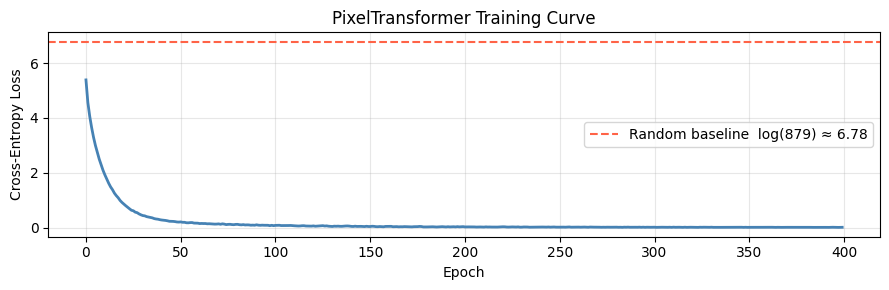

Final loss: 0.0147


In [20]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(loss_history, color='steelblue', lw=2)
ax.axhline(math.log(ROW_VOCAB_SIZE), color='tomato', ls='--', lw=1.5,
           label=f'Random baseline  log({ROW_VOCAB_SIZE}) ≈ {math.log(ROW_VOCAB_SIZE):.2f}')
ax.set_xlabel('Epoch');  ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('PixelTransformer Training Curve', fontweight='500')
ax.legend();  ax.grid(alpha=0.3)
plt.tight_layout();  plt.show()
print(f"Final loss: {loss_history[-1]:.4f}")


## 🎮 Step 7 — Generation & Visualisation

Three final functions to implement:

1. **`decode_sequence`** — turn a list of row token IDs back into a pixel grid.
2. **`generate_sprite`** — temperature-sample new rows autoregressively.
3. **`render_sprite`** — display a pixel grid as a pixel art image with matplotlib.


In [21]:
def decode_sequence(row_id_sequence, id_to_row):
    """
    Convert a list of row token IDs to a 2-D numpy pixel grid.

    Args
    ----
    row_id_sequence : list of ints   — row token IDs (length = num rows)
    id_to_row       : dict           — maps int → row tuple of 16 colour IDs

    Returns
    -------
    grid : np.ndarray  shape (len(row_id_sequence), 16)  dtype uint8
           Each row contains 16 palette colour IDs.
    """
    # TODO 15: Build a list of rows, then convert to numpy array.
    #
    # For each row_id in row_id_sequence:
    #   - look up id_to_row[row_id]  → tuple of 16 colour IDs
    #   - convert to a list
    # Then: np.array(rows, dtype=np.uint8)
    #
    # Hint: rows = [list(id_to_row[rid]) for rid in row_id_sequence]
    rows = [list(id_to_row[rid]) for rid in row_id_sequence]
    return np.array(rows, dtype=np.uint8)

# Quick test
test_seq  = encode_sprite(SPRITES_IDS[0], row_to_id)
test_grid = decode_sequence(test_seq, id_to_row)
print(f"decode_sequence output shape : {test_grid.shape}")
print(f"Max colour ID                : {test_grid.max()}  (should be ≤ 15)")
round_trip = np.array_equal(test_grid, SPRITES_IDS[0])
print(f"Round-trip identical to original : {round_trip}")


decode_sequence output shape : (16, 16)
Max colour ID                : 15  (should be ≤ 15)
Round-trip identical to original : True


<details>
<summary>💡 Hint — TODO 15</summary>

```python
rows = [list(id_to_row[rid]) for rid in row_id_sequence]
```

**Why is `np.array_equal` useful here?**
It's a round-trip test: `SPRITES_IDS[0]` → `encode_sprite` → `decode_sequence`
should give back the exact same pixel grid. If it doesn't, one of TODO 3–5
has a bug (rows not being hashed/looked up correctly).
</details>


In [22]:
def generate_sprite(seed_row_ids, num_generate=8, temperature=0.9):
    """
    Autoregressively generate `num_generate` new rows.

    Args
    ----
    seed_row_ids : list of ints  — row token IDs for the seed rows (top of sprite)
    num_generate : int           — how many new rows to generate
    temperature  : float         — < 1 safer, > 1 more adventurous

    Returns
    -------
    full_grid : np.ndarray  shape (len(seed)+num_generate, 16)
    """
    model.eval()
    ctx       = list(seed_row_ids[-CONTEXT_LEN:])   # sliding context window
    generated = list(seed_row_ids)                   # full sequence so far

    with torch.no_grad():
        for _ in range(num_generate):
            x      = torch.tensor([ctx], dtype=torch.long)   # (1, CONTEXT_LEN)
            logits = model(x)[0, -1, :]                       # (VOCAB_SIZE,)

            # TODO 16a: Divide logits by temperature.
            logits = logits / temperature

            # TODO 16b: Apply softmax to get probabilities.
            probs  = F.softmax(logits, dim=-1)

            # TODO 16c: Sample one row token ID from the distribution.
            next_id = torch.multinomial(probs, num_samples=1).item()

            generated.append(next_id)
            ctx = ctx[1:] + [next_id]    # slide window

    return decode_sequence(generated, id_to_row)

# Quick test
seed_ids = encode_sprite(SPRITES_IDS[0], row_to_id)[:8]
result   = generate_sprite(seed_ids, num_generate=8, temperature=0.9)
print(f"generate_sprite output shape: {result.shape}   (should be (16, 16))")


generate_sprite output shape: (16, 16)   (should be (16, 16))


<details>
<summary>💡 Hint — TODO 16</summary>

```python
logits  = logits / temperature
probs   = F.softmax(logits, dim=-1)
next_id = torch.multinomial(probs, num_samples=1).item()
```

Same three lines as the music notebook.
`torch.multinomial` draws one sample proportional to `probs`.
`.item()` converts the 0-D tensor to a plain Python int so it can
be appended to `generated` and used as a dict key in `decode_sequence`.

**Try `temperature=0.5` vs `temperature=1.3`:**
At 0.5 the model plays it very safe — completions look similar to training sprites.
At 1.3 it takes risks — completions become more abstract and surreal.
</details>


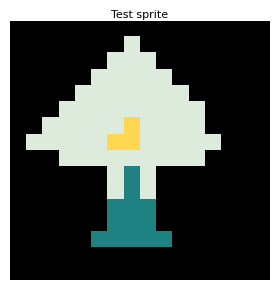

✅ render_sprite working!


In [25]:
def render_sprite(pixel_grid, ax=None, title="", zoom=8):
    """
    Display a 2-D palette-ID grid as a pixel art image.

    Args
    ----
    pixel_grid : np.ndarray  shape (H, W)  values 0–15
    ax         : matplotlib Axes (creates a new one if None)
    title      : string for the subplot title
    zoom       : upscale factor for the displayed image

    Returns
    -------
    ax : the matplotlib Axes used
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(zoom*0.4, zoom*0.4))

    # TODO 17: Convert pixel_grid from palette IDs to an RGB image, then display.
    #
    # Step 1: Index PALETTE with pixel_grid to get an RGB array.
    #         PALETTE has shape (16, 3).  pixel_grid has shape (H, W).
    #         Result should have shape (H, W, 3).
    #         Hint: rgb = PALETTE[pixel_grid]
    #
    # Step 2: Display with ax.imshow(rgb, interpolation='nearest').
    #         `interpolation='nearest'` keeps crisp pixel edges (no blurring).
    #
    rgb = PALETTE[pixel_grid]
    ax.imshow(rgb, interpolation='nearest', aspect='equal')
    if title:
        ax.set_title(title, fontsize=8, pad=2)
    ax.axis('off')
    return ax

# Quick test — should show a colourful sprite
fig, ax = plt.subplots(figsize=(3,3))
render_sprite(SPRITES_IDS[0], ax=ax, title="Test sprite")
plt.tight_layout()
plt.show()
print("✅ render_sprite working!")


<details>
<summary>💡 Hint — TODO 17</summary>

```python
rgb = PALETTE[pixel_grid]          # (H, W, 3) fancy indexing
ax.imshow(rgb, interpolation='nearest', aspect='equal')
```

**What is `PALETTE[pixel_grid]`?**
NumPy's *fancy indexing*: using an array of integers as indices.
`pixel_grid` contains values 0–15; NumPy uses each value to select
a row from `PALETTE`. The result has one RGB triplet per pixel.

**Why `interpolation='nearest'`?**
The default interpolation (`bilinear`) blurs pixels together when displayed
at a larger-than-native size. `nearest` replicates each pixel exactly,
giving the sharp square-pixel look that makes pixel art distinct.
</details>


## 🖼️ Step 8 — See What Your Model Imagines

*Just run these cells — no blanks.*

For each sprite type, we:
1. Take the **top 8 rows** of a real sprite (the seed).
2. Ask the model to **complete the bottom 8 rows**.
3. Show: original sprite | seed only | model completion.


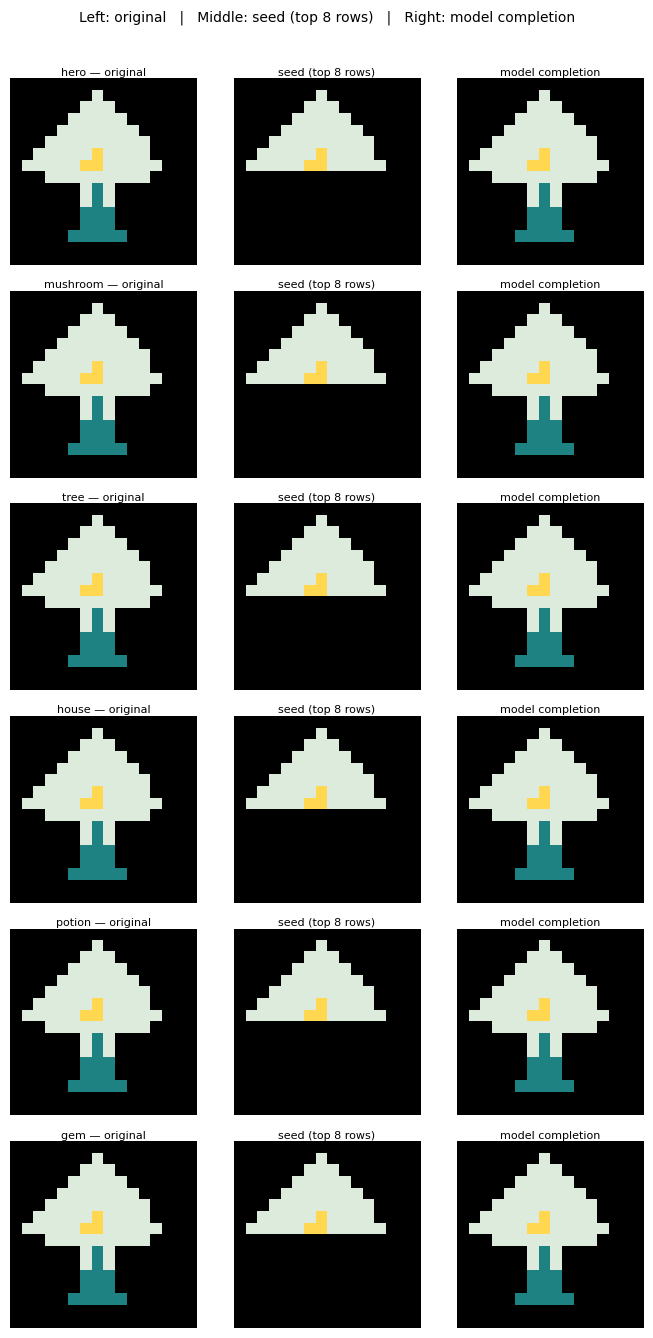

In [26]:
model.eval()
categories = list(TEMPLATES.keys())
fig, axes  = plt.subplots(len(categories), 3, figsize=(7, len(categories)*2.2))
fig.suptitle("Left: original   |   Middle: seed (top 8 rows)   |   Right: model completion",
             fontsize=10, fontweight='500', y=1.01)

sprites_by_cat = {cat: [] for cat in categories}
for sprite_ids in SPRITES_IDS:
    for idx, (cat, tmpl) in enumerate(TEMPLATES.items()):
        if len(sprites_by_cat[cat]) < 1:
            row_ids = encode_sprite(sprite_ids, row_to_id)
            sprites_by_cat[cat].append((sprite_ids, row_ids))

for row_idx, cat in enumerate(categories):
    sprite_ids, row_ids = sprites_by_cat[cat][0]
    seed_ids = row_ids[:8]

    seed_grid     = decode_sequence(seed_ids, id_to_row)
    padding       = np.zeros((8, 16), dtype=np.uint8)
    seed_with_pad = np.vstack([seed_grid, padding])

    completion    = generate_sprite(seed_ids, num_generate=8, temperature=0.85)

    render_sprite(sprite_ids,    ax=axes[row_idx, 0], title=f"{cat} — original")
    render_sprite(seed_with_pad, ax=axes[row_idx, 1], title="seed (top 8 rows)")
    render_sprite(completion,    ax=axes[row_idx, 2], title="model completion")

plt.tight_layout()
plt.show()


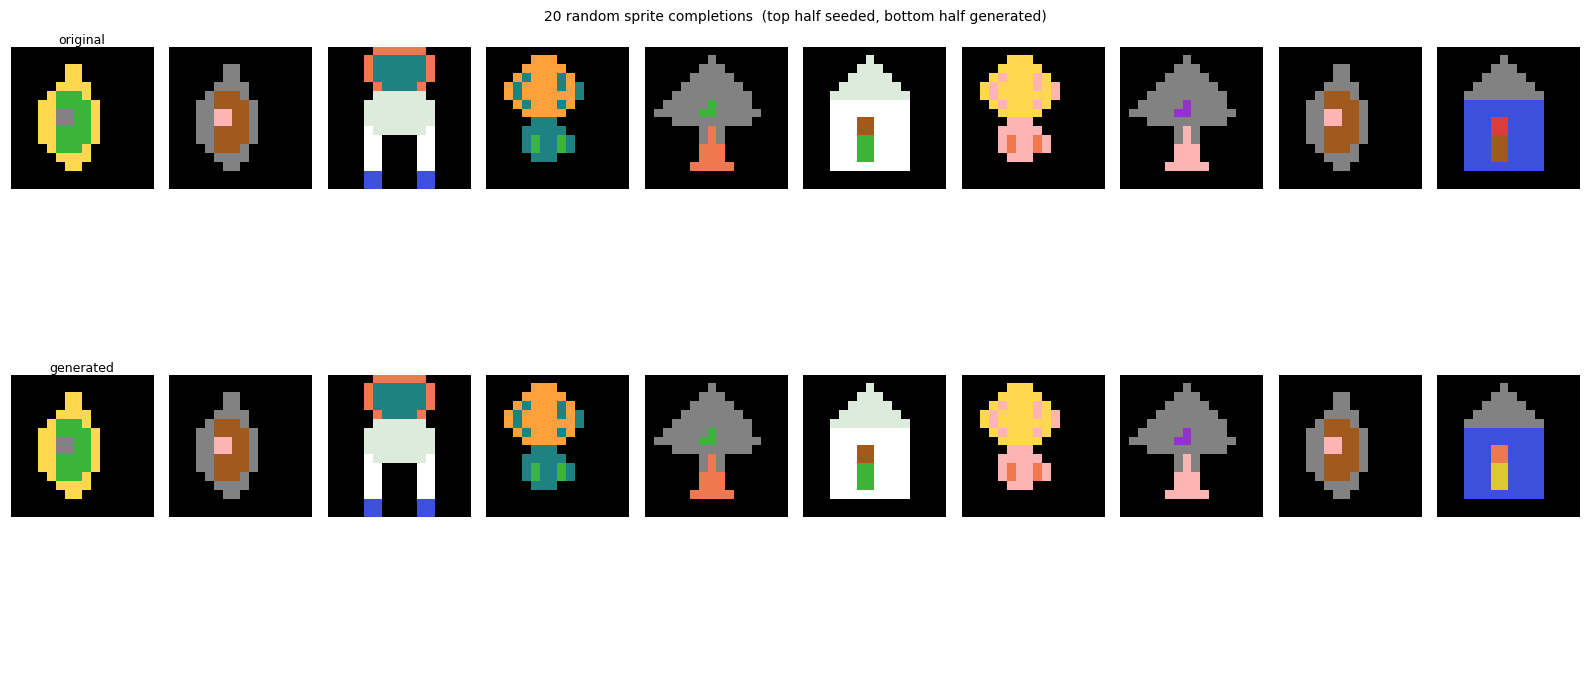

In [27]:
# ── Random generation gallery ─────────────────────────────────────────────────
# Pick 20 random sprites, seed with their top 8 rows, generate 8 more.
np.random.seed(0)
fig, axes = plt.subplots(4, 10, figsize=(16, 7))

for col, ax_pair in enumerate(zip(axes[:2].T, axes[2:].T)):
    ax_orig, ax_gen = ax_pair[0][0], ax_pair[1][0]
    # pick a random sprite
    sprite_ids = random.choice(SPRITES_IDS)
    row_ids    = encode_sprite(sprite_ids, row_to_id)
    seed_ids   = row_ids[:8]
    completion = generate_sprite(seed_ids, num_generate=8, temperature=0.9)
    render_sprite(sprite_ids, ax=ax_orig, title="orig" if col==0 else "")
    render_sprite(completion, ax=ax_gen,  title="gen"  if col==0 else "")

for ax in axes.flat:
    ax.axis('off')

axes[0,0].set_title("original", fontsize=9, pad=2)
axes[2,0].set_title("generated", fontsize=9, pad=2)
fig.suptitle("20 random sprite completions  (top half seeded, bottom half generated)",
             fontsize=10, fontweight='500')
plt.tight_layout()
plt.show()


## 🧠 Bonus Challenges

### 🟢 Easy
1. **Temperature sweep.** For one sprite, generate 5 completions at temperatures
   `[0.4, 0.6, 0.8, 1.0, 1.2]`. Display them side by side. Describe in one sentence
   what changes at each extreme.
2. **Cross-category seeding.** Use the top 8 rows of a *tree* sprite as a seed
   but complete with a model retrained only on *hero* sprites. What comes out?
3. **Longer generation.** Change `num_generate=12` (generate 75% of the sprite
   instead of 50%). Does quality degrade further down?

### 🟡 Medium
4. **Real sprites.** Download a free 16×16 sprite sheet from
   [opengameart.org](https://opengameart.org) or [itch.io](https://itch.io).
   Slice it into individual sprites, run them through your quantisation pipeline
   (TODO 1–2), and add them to the training set. Does the model generalise better?
5. **Sprite interpolation.** Take the top 8 rows of sprite A and the bottom 8 rows
   of sprite B. Feed the top 8 as a seed and generate. You've created a hybrid.
   Try hero-top + mushroom-seed. What does the model produce?
6. **Bigger model.** Set `D_MODEL=128`, `N_LAYERS=3`, `D_FF=256`. Retrain.
   Does generated quality improve? How many more parameters does it have?

### 🔴 Hard
7. **Pixel-level prediction.** Redesign the model to predict one **pixel** at a time
   instead of one row. The context is the previous `N` pixels (reading order:
   left-to-right, top-to-bottom). Vocabulary size drops to 16 (palette size).
   Compare the generated images — is pixel-level or row-level better?
8. **Symmetry loss.** Most sprites are left-right symmetric. Add a custom loss term
   that penalises asymmetry in generated rows:
   `sym_loss = F.mse_loss(logits, logits.flip(-1))`.
   Does training with this constraint produce more symmetric sprites?
9. **Encoder-decoder.** Train two models: an encoder that maps a full sprite to
   a 64-D latent vector, and a decoder that generates rows conditioned on that vector.
   At generation time, encode a real sprite and decode it — you get a "reconstructed"
   version. This is the architecture of a VAE.

---

## 🎓 What you built

| Pipeline stage | You implemented |
|---------------|----------------|
| Colour quantisation | nearest-palette search with squared L2 distance |
| Row tokenisation | sprite → row tuples → vocabulary → IDs |
| Pixel-aware embedding | RowEncoder: colour emb → flatten → project |
| Autoregressive generation | sliding-window temperature sampling |
| Visual decoding | fancy index into palette → imshow |

The data pipeline (TODOs 1–7) is the hardest part and the most transferable skill.
It's a miniature version of what every computer vision team does: raw images →
normalised, tokenised representations that a model can process.

The model itself (TODOs 8–12) is identical in structure to the music notebook —
because the architecture doesn't care whether tokens are notes, rows, or words.
That's the point: **one architecture, many domains**.
